<a href="https://colab.research.google.com/github/Murcha1990/ML_AI25/blob/main/Lesson14_PCA%26Embeddings/PCA_image_reduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# We will take a colored picture and will use PCA to reduce its dimension and then reconstruct the image to visulize.

## Import all the libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import cv2
from scipy.stats import stats
import matplotlib.image as mpimg

## Prepare the data

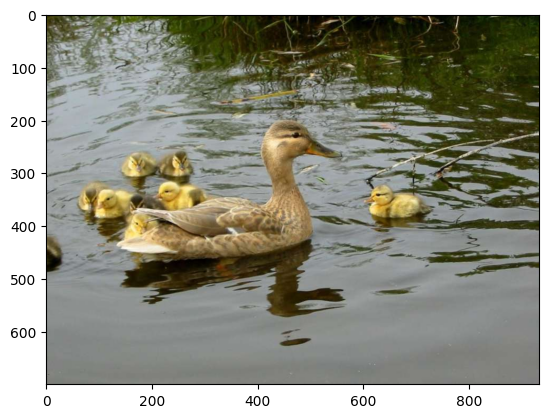

In [ ]:
img = cv2.cvtColor(cv2.imread('duck.jpg'), cv2.COLOR_BGR2RGB)
#img = cv2.imread('rose.png')
plt.imshow(img)
plt.show()

In [ ]:
img.shape

(700, 933, 3)

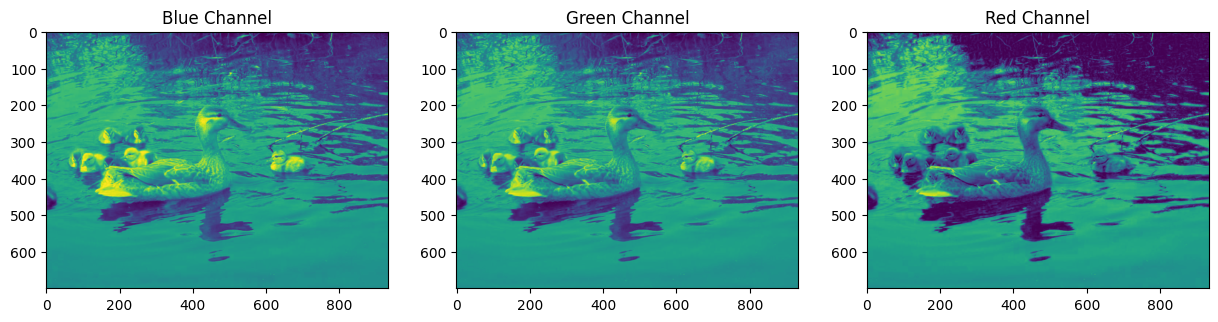

In [ ]:
#Splitting into channels
blue,green,red = cv2.split(img)

# Plotting the images
fig = plt.figure(figsize = (15, 7.2))
fig.add_subplot(131)
plt.title("Blue Channel")
plt.imshow(blue)

fig.add_subplot(132)
plt.title("Green Channel")
plt.imshow(green)

fig.add_subplot(133)
plt.title("Red Channel")
plt.imshow(red)

plt.show()

## Check the data of the blue channel

In [ ]:
blue_temp_df = pd.DataFrame(data = blue)
blue_temp_df

,0,1,2,3,4,5,6,7,8,9,...,923,924,925,926,927,928,929,930,931,932
0,48,45,43,48,57,63,63,60,54,62,...,6,2,2,6,10,4,6,10,13,14
1,48,48,50,53,56,56,52,49,51,58,...,8,5,5,8,11,8,11,17,23,27
2,50,54,58,58,54,47,43,40,47,52,...,9,6,4,5,6,8,11,16,21,25
3,55,60,63,60,51,45,43,45,50,53,...,19,15,10,8,8,13,14,15,16,16
4,62,64,64,58,51,49,54,59,63,63,...,32,27,21,17,15,23,22,21,19,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
695,125,125,125,125,125,125,125,125,125,125,...,126,126,126,126,126,129,129,129,129,129
696,126,126,126,126,126,126,126,126,125,125,...,127,128,128,127,127,129,129,129,129,129
697,126,126,126,126,126,126,126,126,125,125,...,128,128,128,127,127,129,129,129,129,129
698,126,126,126,126,126,126,126,126,125,125,...,128,129,128,128,127,129,129,129,129,129


## Perform PCA

## Scale the data

In [ ]:
df_blue = blue/255
df_green = green/255
df_red = red/255

## Fit the data in PCA

In [ ]:
pca_b = PCA(n_components=30)
pca_b.fit(df_blue)
trans_pca_b = pca_b.transform(df_blue)

pca_g = PCA(n_components=30)
pca_g.fit(df_green)
trans_pca_g = pca_g.transform(df_green)

pca_r = PCA(n_components=30)
pca_r.fit(df_red)
trans_pca_r = pca_r.transform(df_red)

print(trans_pca_b.shape)
print(trans_pca_r.shape)
print(trans_pca_g.shape)

(700, 30)
(700, 30)
(700, 30)


### Lets plot a bar chart to check the explained variance ratio by each Eigen values

In [ ]:
print(f"Blue Channel : {sum(pca_b.explained_variance_ratio_)}")
print(f"Green Channel: {sum(pca_g.explained_variance_ratio_)}")
print(f"Red Channel  : {sum(pca_r.explained_variance_ratio_)}")

Blue Channel : 0.9123506694034821
Green Channel: 0.9104601081256274
Red Channel  : 0.9369629511104473


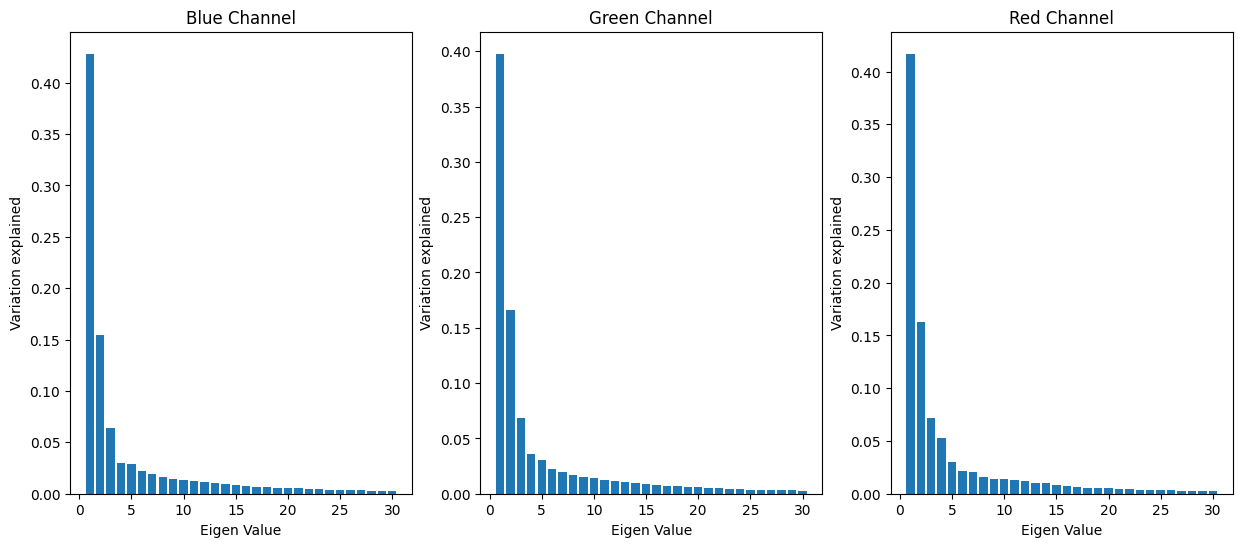

In [ ]:
fig = plt.figure(figsize = (15, 6))
fig.add_subplot(131)
plt.title("Blue Channel")
plt.ylabel('Variation explained')
plt.xlabel('Eigen Value')
plt.bar(list(range(1,31)),pca_b.explained_variance_ratio_)

fig.add_subplot(132)
plt.title("Green Channel")
plt.ylabel('Variation explained')
plt.xlabel('Eigen Value')
plt.bar(list(range(1,31)),pca_g.explained_variance_ratio_)

fig.add_subplot(133)
plt.title("Red Channel")
plt.ylabel('Variation explained')
plt.xlabel('Eigen Value')
plt.bar(list(range(1,31)),pca_r.explained_variance_ratio_)
plt.show()

### Reconstruct to validate and visualize

In [ ]:
b_arr = pca_b.inverse_transform(trans_pca_b)
g_arr = pca_g.inverse_transform(trans_pca_g)
r_arr = pca_r.inverse_transform(trans_pca_r)
print(b_arr.shape, g_arr.shape, r_arr.shape)

(700, 933) (700, 933) (700, 933)


In [ ]:
img_reduced= cv2.merge((b_arr, g_arr, r_arr))
print(img_reduced.shape)

(700, 933, 3)


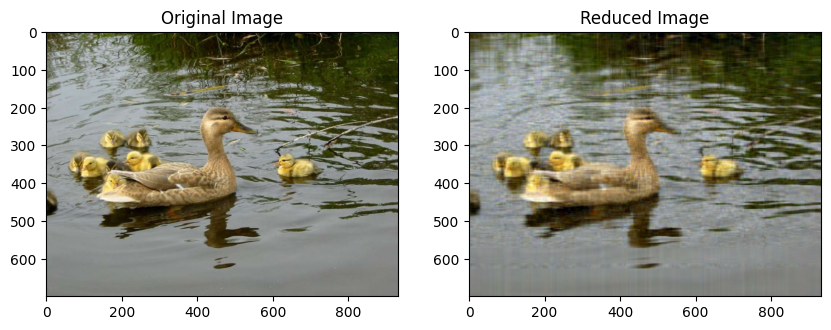

In [ ]:
fig = plt.figure(figsize = (10, 7.2))
fig.add_subplot(121)
plt.title("Original Image")
plt.imshow(img)

fig.add_subplot(122)
plt.title("Reduced Image")
plt.imshow(img_reduced)
plt.show()